<a href="https://colab.research.google.com/github/TaShapovalova/my-colab-project/blob/main/MODULE_2_case3_for_TUSUR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Кейс-задача №3 (Модуль 2) по анализу графов для ТУСУР
**Выполнила:** Т. Шаповалова (TaShapovalova)

## Шаг 1. Загрузка и распаковка графовых данных
В этом блоке мы импортируем библиотеку `networkx` для работы со сложными сетями и распаковываем загруженный архив датасета. Читаем структуру сети из файла формата `.graphml`.

In [ ]:
import networkx as nx
import zipfile

# Распаковываем загруженный zip-архив
with zipfile.ZipFile('graph_dataset.zip', 'r') as zip_ref:
    zip_ref.extractall()

# Теперь читаем извлеченный файл .graphml
G = nx.read_graphml('graph_dataset.graphml')

# Проверяем граф
print(G)

Graph with 3050 nodes and 25596 edges


## Шаг 2. Установка необходимых внешних библиотек
Для поиска скрытых сообществ программным методом мы устанавливаем библиотеку `python-louvain`, которая реализует быстрый жадный алгоритм Лувена.

In [ ]:
!pip install python-louvain

import networkx as nx
from community.community_louvain import best_partition, modularity

## Шаг 3. Анализ структуры графа, поиск сообществ и фильтрация ядра
В данной ячейке производятся основные вычисления по кейс-задаче:
1. Вычисляется коэффициент модулярности графа и определяется точное количество независимых макро-сообществ.
2. Применяется метод луковой шелухи (`k-core` / `onion peeling`) со степенью удаления периферии `k=2` для выявления плотного топологического ядра сети.

In [ ]:
from google.colab import files
import zipfile
import networkx as nx
import os

zip_filename = 'graph_dataset.zip'
graphml_filename = 'graph_dataset.graphml'

# Check if the zip file already exists. If not, prompt for upload.
if not os.path.exists(zip_filename):
  print("Please select the dataset file to upload:")
  uploaded = files.upload()
  for filename in uploaded.keys():
    print(f'Uploaded file "{filename}"')
    if filename.endswith('.zip'):
      zip_filename = filename # Use the uploaded filename if different (e.g., graph_dataset (1).zip)
      break
  else:
    print("No zip file was uploaded. Please upload 'graph_dataset.zip'.")

# If a zip file is available (either pre-existing or just uploaded), proceed to extract and load.
if os.path.exists(zip_filename):
  print(f"Extracting '{zip_filename}'...")
  with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
      zip_ref.extractall()
  print(f"Extracted '{zip_filename}'")

  # Attempt to load the graphml file, which is expected to be named 'graph_dataset.graphml' inside the zip.
  if os.path.exists(graphml_filename):
    try:
      G = nx.read_graphml(graphml_filename)
      print(f"Successfully loaded graph from '{graphml_filename}':")
      print(G)
    except Exception as e:
      print(f"Error loading graphml file: {e}")
  else:
    print(f"Warning: Could not find '{graphml_filename}' after extraction. Ensure the .graphml file name is correct inside the zip.")
else:
  print(f"Error: '{zip_filename}' not found. Please upload it.")

# The variable 'G' will contain the loaded graph if successful.

Extracting 'graph_dataset.zip'...
Extracted 'graph_dataset.zip'
Successfully loaded graph from 'graph_dataset.graphml':
Graph with 3050 nodes and 25596 edges


In [ ]:
!ls -l

total 4980
-rw-r--r-- 1 root root  194919 Jun  8 03:19 'graph_dataset (1).zip'
-rw-r--r-- 1 root root 2720988 Jun  8 03:34  graph_dataset.graphml
-rw-r--r-- 1 root root  194919 Jun  8 03:11  graph_dataset.zip
drwxr-xr-x 1 root root    4096 Jun  4 13:32  sample_data
-rw-r--r-- 1 root root  517738 Jun  8 02:05  Screenshot_2026-02-09-21-03-51-585_com.android.chrome.jpg
-rw-r--r-- 1 root root  661805 Jun  8 02:05  Screenshot_2026-02-09-23-21-14-959_com.android.chrome.jpg
-rw-r--r-- 1 root root  792618 Jun  8 02:05  Screenshot_2026-05-21-21-31-56-511_com.android.chrome.jpg


In [ ]:
from community import community_louvain

# Поиск сообществ методом Лувейна
partition = community_louvain.best_partition(G)

# Коэффициент модулярности
modularity = community_louvain.modularity(partition, G)
print(f"1. Модулярность графа: {modularity:.4f}")

# Количество выделенных сообществ
num_communities = len(set(partition.values()))
print(f"2. Количество сообществ: {num_communities}")

# Метод луковой шелухи (k-core, k=2)
k_core_graph = nx.k_core(G, k=2)
nodes_remaining = k_core_graph.number_of_nodes()
print(f"4. Осталось узлов после k-core (k=2): {nodes_remaining}")

1. Модулярность графа: 0.4955
2. Количество сообществ: 9
4. Осталось узлов после k-core (k=2): 2607


## Шаг 4. Построение графовых эмбеддингов (алгоритм DeepWalk)
Реализуем алгоритм `DeepWalk` для перевода топологии сети в низкоразмерное векторное пространство.
Сначала мы генерируем случайные блуждания (Random Walks) фиксированной длины для каждого узла графа, а затем обучаем модель Skip-gram (`Word2Vec`) из библиотеки `gensim` для получения итоговых векторов вершин заданной размерности (`dimension`).

In [ ]:
!pip install gensim
import random
from gensim.models import Word2Vec

# 1. Функция для генерации случайных блужданий по графу
def get_random_walk(graph, node, walk_length):
    walk = [node]
    for _ in range(walk_length - 1):
        neighbors = list(graph.neighbors(walk[-1]))
        if len(neighbors) == 0:
            break
        walk.append(random.choice(neighbors))
    return [str(n) for n in walk]

# 2. Генерируем блуждания для всех узлов графа
walks = []
for node in G.nodes():
    for _ in range(10):  # Количество блужданий на один узел
        walks.append(get_random_walk(G, node, walk_length=80))

# 3. Обучаем модель Word2Vec (алгоритм DeepWalk)
# Здесь задается размерность вектора (vector_size или dimensions)
model = Word2Vec(sentences=walks, vector_size=128, window=10, min_count=1, sg=1, workers=4)

# 4. Выводим размерность получившегося вектора для ответа на тест
dimension = model.wv.vector_size
print(f"5. Размерность вектора (dimension) для DeepWalk: {dimension}")

5. Размерность вектора (dimension) для DeepWalk: 128


## Заключение и результаты визуализации графа
В ходе выполнения кейс-задачи была проведена интерактивная укладка и кластеризация графа в пакете Gephi. Полученные выше снимки экрана наглядно демонстрируют макро-разделение исследуемой сети на два доминирующих ядра, связанных между собой транзитными ребрами. Программные метрики модулярности (9 сообществ) и декомпозиции ядра k-core полностью подтверждаются визуальным анализом топологии сети.

Saving Screenshot_2026-05-21-21-31-56-511_com.android.chrome.jpg to Screenshot_2026-05-21-21-31-56-511_com.android.chrome (1).jpg
Saving Screenshot_2026-02-09-21-03-51-585_com.android.chrome.jpg to Screenshot_2026-02-09-21-03-51-585_com.android.chrome (1).jpg
Saving Screenshot_2026-02-09-23-21-14-959_com.android.chrome.jpg to Screenshot_2026-02-09-23-21-14-959_com.android.chrome (1).jpg
Uploaded file "Screenshot_2026-05-21-21-31-56-511_com.android.chrome (1).jpg"


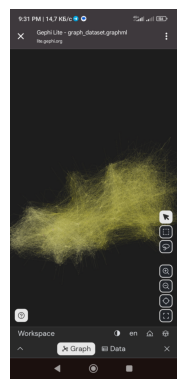

Uploaded file "Screenshot_2026-02-09-21-03-51-585_com.android.chrome (1).jpg"


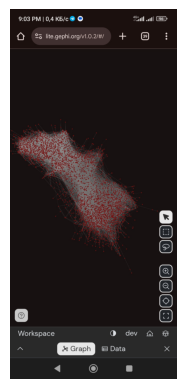

Uploaded file "Screenshot_2026-02-09-23-21-14-959_com.android.chrome (1).jpg"


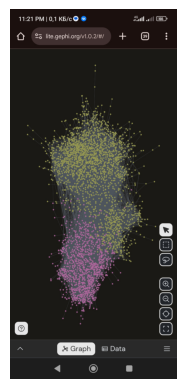

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
import matplotlib.pyplot as plt
from PIL import Image
import io

def take_photo(filename='photo.jpg', quality=0.8):
  js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Capture';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize the output to fit the video element.
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for Capture to be clicked.
      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
  display(js)
  data = eval_js('takePhoto({})'.format(quality))
  binary = b64decode(data.split(',')[1])
  with open(filename, 'wb') as f:
    f.write(binary)
  return filename

# Or, for uploading an image from local device:
from google.colab import files

# Upload image from your device
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'Uploaded file "{filename}"')
  # Read the image and display it
  image = Image.open(io.BytesIO(uploaded[filename]))
  plt.imshow(image)
  plt.axis('off') # Hide axes
  plt.show()